# NextBuy — EDA & Machine Learning
## From Raw Data to Smart Decisions
> **Équipe** : Simon (SLACK) · Sebag · Léger

### Business Questions
1. Which products are the bestsellers by department?
2. When do customers usually order? (day & hour)
3. Which item do customers put in their cart first?
4. What is the average cart size?
5. What is the proportion of healthy vs unhealthy products ordered?
6. Which products should be emphasized on weekends?
7. Which products have the highest probability of being reordered?
8. Can we predict whether a produce product is healthy using nutritional data from an external API?


## Data Loading & Preprocessing
> *Source : Léger*

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import squarify
import requests
import time
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, classification_report,
                              roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')


In [36]:
aisles = pd.read_csv('./datasets/aisles.csv')
departments = pd.read_csv('./datasets/departments.csv')
products = pd.read_csv('./datasets/products.csv')
orders = pd.read_csv('./datasets/orders.csv')
order_products = pd.read_csv('./datasets/order_products.csv') 

aisles = aisles.dropna(subset=['aisle_id' , 'aisle'])
departments = departments.dropna(subset=['department_id' , 'department'])
order_products = order_products.dropna(subset=['order_id','product_id'])
orders = orders.dropna(subset=["order_id","user_id","order_dow"])
products = products.dropna(subset=['product_id','product_name'])

products_enriched = products.merge(aisles, on='aisle_id', how='left')
products_enriched = products_enriched.merge(departments, on='department_id', how='left')
orders_details = order_products.merge(orders, on='order_id', how='left')
df_master = orders_details.merge(products_enriched, on='product_id', how='left')

In [37]:
print('NaN par colonne :')
display(df_master.isnull().sum().to_frame('NaN count'))


NaN par colonne :


,NaN count
order_id,0
product_id,0
add_to_cart_order,446
reordered,449
user_id,555
eval_set,799
order_number,758
order_dow,555
order_hour_of_day,879507
days_since_prior_order,13692437


---
## Q1 — Which products are the bestsellers by department?
> *Source : Simon*

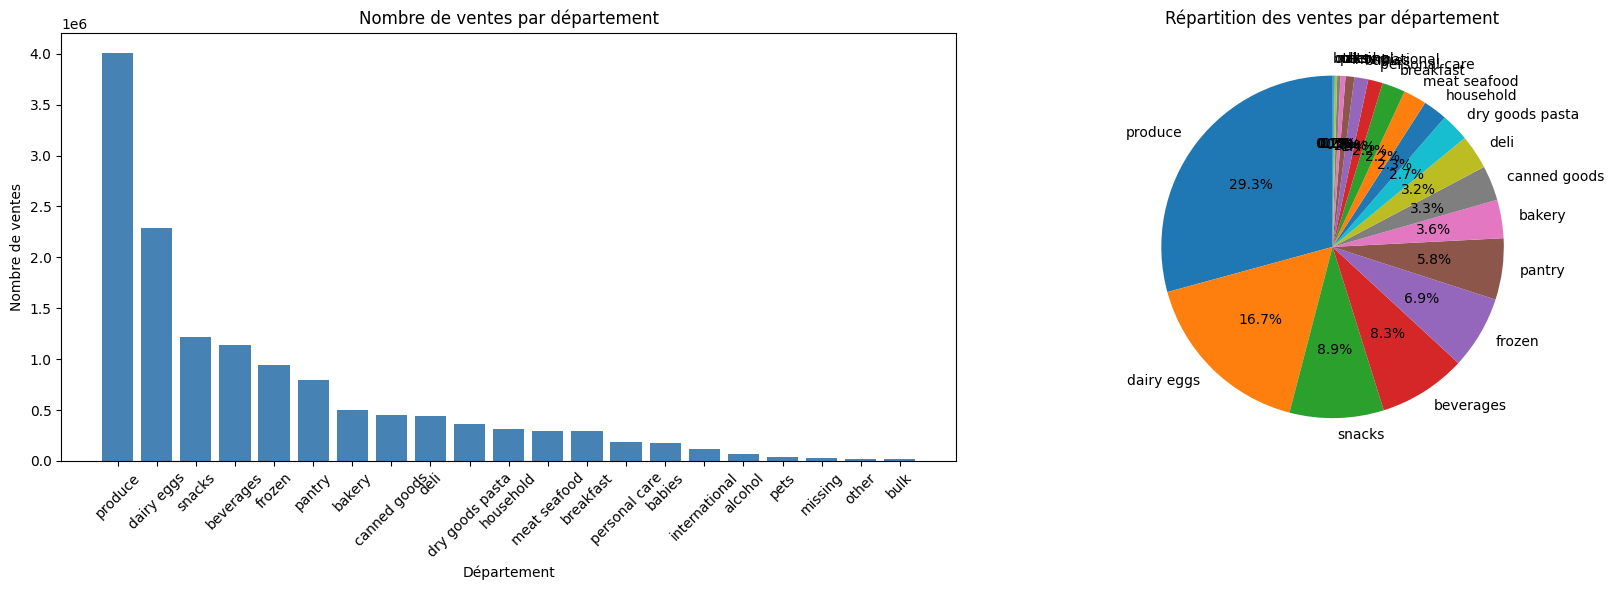

In [38]:
ventes_par_dept = df_master.groupby('department').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].bar(ventes_par_dept.index, ventes_par_dept.values, color='steelblue')
axes[0].set_title('Nombre de ventes par département')
axes[0].set_xlabel('Département')
axes[0].set_ylabel('Nombre de ventes')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(ventes_par_dept.values, labels=ventes_par_dept.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Répartition des ventes par département')

plt.tight_layout()
plt.show()


In [39]:
ventes = (
    df_master.groupby(['department', 'product_name'], as_index=False)
    .size().rename(columns={'size': 'nb_achats'})
)
top_per_dept = ventes.sort_values('nb_achats', ascending=False).groupby('department').head(1)
display(top_per_dept.sort_values('nb_achats', ascending=False).reset_index(drop=True))


,department,product_name,nb_achats
0,produce,Banana,199654
1,dairy eggs,Organic Whole Milk,58210
2,beverages,Sparkling Water Grapefruit,31997
3,deli,Original Hummus,30109
4,bakery,100% Whole Wheat Bread,25559
5,frozen,Blueberries,23792
6,pantry,Extra Virgin Olive Oil,21386
7,meat seafood,Boneless Skinless Chicken Breasts,21188
8,canned goods,Organic Black Beans,16059
9,household,100% Recycled Paper Towels,11774


---
## Q2 — When do customers usually order?
> *Source : Sebag (peak days) · Léger (peak hours)*

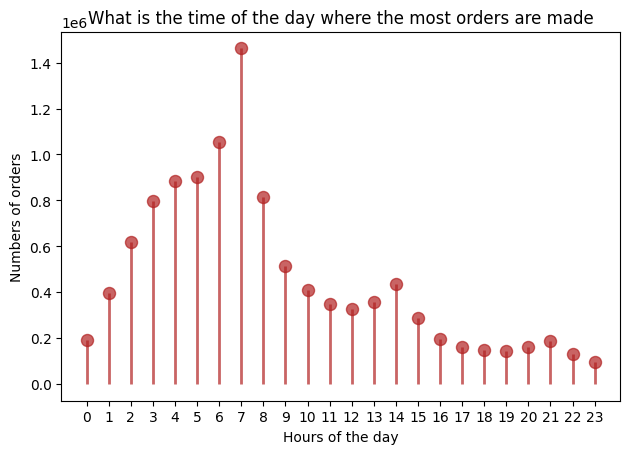

In [41]:
df_hours = (
    df_master["order_hour_of_day"]
    .dropna()
    .astype(int)
    .pipe(lambda s: s[s.between(0, 23)])
    .value_counts()
    .sort_index()
)
fig, ax = plt.subplots()
ax.set_title('What is the time of the day where the most orders are made')
ax.vlines(x=df_hours.index, ymin=0, ymax=df_hours , color='firebrick', alpha=0.7, linewidth=2)
ax.scatter(x=df_hours.index, y=df_hours, s=75, color='firebrick', alpha=0.7)
ax.set_xticks(df_hours.index)
ax.set_xlabel('Hours of the day')
ax.set_ylabel('Numbers of orders')
plt.tight_layout()

---
## Q3 — Which item do customers put in their cart first?
> *Source : Léger*

In [ ]:
first_items = (
    df_master[df_master['add_to_cart_order'] == 1]['product_name']
    .dropna().value_counts().head(5)
)
display(first_items)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(first_items, labels=first_items.index, autopct='%1.1f%%')
ax.set_title('Which item do customers put in their cart first?')
plt.tight_layout()
plt.show()


---
## Q4 — What is the average cart size?
> *Source : Léger*

In [ ]:
cart_sizes = df_master.groupby('order_id')['product_id'].count()
avg_cart   = cart_sizes.mean()
size_dist  = cart_sizes.value_counts().sort_index().head(30)

fig, ax = plt.subplots(figsize=(10, 6))
squarify.plot(
    sizes=size_dist.values,
    label=[f'{k} articles' for k in size_dist.index],
    color=['#91DCEA', '#64CDCC', '#5FBB68', '#F9D23C', '#F9A729', '#FD6F30'],
    ax=ax
)
ax.set_title(f'Treemap of the size of the carts (moyenne : {avg_cart:.1f} articles)')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Taille moyenne du panier : {avg_cart:.2f} articles')


---
## Q5 — What is the proportion of healthy vs unhealthy products ordered by department?
> *Source : Simon*

In [ ]:
healthy_keywords = [
    'protein', 'whey', 'casein', 'egg white', 'tuna', 'chicken breast', 'turkey',
    'tofu', 'tempeh', 'edamame', 'organic', 'natural', 'whole grain', 'multigrain',
    'whole wheat', 'sugar free', 'sugar-free', 'fat free', 'fat-free', 'low fat',
    'low-fat', 'low calorie', 'low carb', 'low sodium', 'light', 'reduced',
    'zero', 'no added sugar', 'unsweetened', 'kale', 'spinach', 'quinoa',
    'chia', 'flax', 'hemp', 'acai', 'spirulina', 'matcha', 'turmeric', 'ginger',
    'almond', 'cashew', 'walnut', 'oat', 'granola', 'vegan', 'gluten free',
    'gluten-free', 'dairy free', 'dairy-free', 'paleo', 'keto', 'non-gmo',
    'greek yogurt', 'skyr', 'cottage', 'almond milk', 'oat milk',
    'soy milk', 'plant based', 'plant-based'
]
unhealthy_keywords = [
    'chips', 'crackers', 'popcorn', 'pretzel', 'nachos', 'hot dog', 'bacon',
    'sausage', 'pepperoni', 'salami', 'candy', 'chocolate', 'cookie', 'brownie',
    'cake', 'donut', 'muffin', 'waffle', 'pancake', 'syrup', 'frosting', 'fudge',
    'caramel', 'marshmallow', 'gummy', 'soda', 'cola', 'sprite', 'fanta',
    'energy drink', 'lemonade', 'sweetened', 'cream cheese', 'heavy cream',
    'whipped cream', 'butter', 'full fat', 'whole milk', 'mayo', 'mayonnaise',
    'fried', 'deep fried', 'frozen pizza', 'mac and cheese', 'beer', 'wine',
    'vodka', 'whiskey', 'rum', 'tequila', 'ale', 'lager', 'cider', 'jerky'
]

pattern_healthy   = '|'.join(healthy_keywords)
pattern_unhealthy = '|'.join(unhealthy_keywords)

healthy_df   = df_master[df_master['product_name'].str.lower().str.contains(pattern_healthy,   na=False)]
unhealthy_df = df_master[df_master['product_name'].str.lower().str.contains(pattern_unhealthy, na=False)]

all_depts         = unhealthy_df.groupby('department').size().sort_values(ascending=False).index
healthy_aligned   = healthy_df.groupby('department').size().reindex(all_depts, fill_value=0)
unhealthy_aligned = unhealthy_df.groupby('department').size().reindex(all_depts, fill_value=0)

x     = np.arange(len(all_depts))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 7))
ax.bar(x - width/2, unhealthy_aligned.values, width, color='red',   label='Non Healthy')
ax.bar(x + width/2, healthy_aligned.values,   width, color='green', label='Healthy')
ax.set_xticks(x)
ax.set_xticklabels(all_depts, rotation=45, ha='right')
ax.set_title('Healthy vs Non-Healthy par département')
ax.set_xlabel('Département')
ax.set_ylabel('Nombre de ventes')
ax.legend()
plt.tight_layout()
plt.show()


---
## Q6 — Which products should be emphasized on weekends?
> *Source : Sebag*

In [ ]:
# Joindre les produits commandés avec le jour de la commande
df_sales = order_products[['order_id', 'product_id']].merge(
    orders[['order_id', 'order_dow']], on='order_id', how='left'
)


In [ ]:
# Calculer le nombre total de ventes par produit
total_sales = df_sales.groupby('product_id').size().reset_index(name='total_sales')
display(total_sales.head())


In [ ]:
# Calculer le nombre total de ventes spécifiquement le week-end (0=Dimanche, 1=Lundi)
weekend_sales = df_sales[df_sales['order_dow'].isin([0, 1])]
weekend_sales_count = weekend_sales.groupby('product_id').size().reset_index(name='weekend_sales')
display(weekend_sales_count.head())


In [ ]:
# Fusionner pour comparer le total et le week-end
target_df = total_sales.merge(weekend_sales_count, on='product_id', how='left')

# Si un produit n'a jamais été vendu le week-end, on remplace le NaN par 0
target_df['weekend_sales'] = target_df['weekend_sales'].fillna(0)

# Calculer le pourcentage des ventes du weekend (ratio)
target_df['weekend_ratio'] = target_df['weekend_sales'] / target_df['total_sales']

# Créer la variable cible avec un seuil de 40%
seuil = 0.40
target_df['is_weekend_bestseller'] = (target_df['weekend_ratio'] >= seuil).astype(int)

print('Aperçu des produits :')
display(target_df.head(10))

print('\nRépartition de la cible :')
print(target_df['is_weekend_bestseller'].value_counts(normalize=True) * 100)


In [ ]:
top_weekend = (
    target_df[target_df['is_weekend_bestseller'] == 1]
    .merge(products[['product_id', 'product_name']], on='product_id')
    .sort_values('weekend_ratio', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_weekend['product_name'][::-1], top_weekend['weekend_ratio'][::-1], color='coral')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Top 15 produits à mettre en avant le week-end')
ax.set_xlabel('Ratio ventes weekend / total')
plt.tight_layout()
plt.show()


---
## Q7 — Which products have the highest probability of being reordered?
> *Source : Sebag*

### Feature Engineering
On construit des features produit à partir de l'historique de commandes :
- `total_orders` : nombre total de fois qu'un produit a été commandé
- `reorder_rate` : taux de réachat (reorder_count / total_orders)
- `avg_cart_position` / `min_cart_position` : position moyenne/minimale dans le panier
- `unique_users` : nombre d'utilisateurs distincts ayant commandé ce produit
- `is_organic` : flag si le produit est bio

**Cible** : `high_reorder` = 1 si le taux de réachat est supérieur à la médiane.


In [ ]:
products_stats = (
    order_products.groupby('product_id').agg(
        total_orders      = ('order_id', 'count'),
        reorder_count     = ('reordered', 'sum'),
        avg_cart_position = ('add_to_cart_order', 'mean'),
        min_cart_position = ('add_to_cart_order', 'min'),
    ).reset_index()
)
products_stats['reorder_rate'] = products_stats['reorder_count'] / products_stats['total_orders']

median_rate = products_stats['reorder_rate'].median()
products_stats['high_reorder'] = (products_stats['reorder_rate'] >= median_rate).astype(int)

user_counts = (
    order_products
    .merge(orders[['order_id', 'user_id']], on='order_id')
    .groupby('product_id')['user_id'].nunique()
    .reset_index(name='unique_users')
)
products_stats = products_stats.merge(user_counts, on='product_id', how='left')

product_full = (
    products
    .merge(aisles, on='aisle_id')
    .merge(departments, on='department_id')
    .merge(products_stats, on='product_id', how='inner')
)
product_full['is_organic'] = product_full['product_name'].str.lower().str.contains('organic').astype(int)

print('Features construites :')
print(product_full[['product_name', 'department', 'total_orders', 'reorder_rate',
                     'avg_cart_position', 'unique_users', 'is_organic', 'high_reorder']].head())
print(f'\nDataset produits : {product_full.shape[0]:,} produits')
print(f'Médiane du taux de réachat (seuil) : {median_rate:.3f}')
print(f'Répartition de la cible :\n{product_full["high_reorder"].value_counts(normalize=True).mul(100).round(1).to_string()}')


In [ ]:
FEATURES = ['total_orders', 'avg_cart_position', 'min_cart_position', 'unique_users', 'is_organic']

X = product_full[FEATURES]
y = product_full['high_reorder']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=500, random_state=42))
])
pipe_rf = Pipeline([
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1))
])

pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

for name, pipe in [('Logistic Regression', pipe_lr), ('Random Forest', pipe_rf)]:
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    print(f'\n{"="*50}')
    print(f'  {name}  —  AUC-ROC : {auc:.4f}')
    print('='*50)
    print(classification_report(y_test, y_pred, target_names=['Low reorder', 'High reorder']))


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, pipe, color in [
    ('Logistic Regression', pipe_lr, '#4C72B0'),
    ('Random Forest',       pipe_rf, '#DD8452')
]:
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=axes[0], color=color)
axes[0].set_title('Courbes ROC', fontsize=13, fontweight='bold')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('Taux de faux positifs')
axes[0].set_ylabel('Taux de vrais positifs')

for ax, (name, pipe) in zip(axes[1:], [('Logistic Regression', pipe_lr), ('Random Forest', pipe_rf)]):
    ConfusionMatrixDisplay.from_estimator(
        pipe, X_test, y_test, display_labels=['Low', 'High'], colorbar=False, ax=ax, cmap='Blues'
    )
    ax.set_title(f'Matrice de confusion\n{name}', fontsize=12, fontweight='bold')

plt.suptitle('Comparaison des modèles — Prédiction de réachat produit', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Random Forest capte mieux les non-linéarités.')


In [ ]:
importances = (
    pd.Series(pipe_rf['clf'].feature_importances_, index=FEATURES)
    .sort_values(ascending=True)
)
imp_colors = ['#4C72B0' if v < importances.max() else '#DD8452' for v in importances]

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', ax=ax, color=imp_colors, edgecolor='white')
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance relative')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for patch, val in zip(ax.patches, importances):
    ax.text(val + 0.002, patch.get_y() + patch.get_height() / 2, f'{val:.1%}', va='center', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()
print("Le nombre total de commandes et le nombre d'utilisateurs uniques sont les signaux les plus prédictifs.")


In [ ]:
product_full['reorder_proba_rf'] = pipe_rf.predict_proba(product_full[FEATURES])[:, 1]
product_full['reorder_proba_lr'] = pipe_lr.predict_proba(product_full[FEATURES])[:, 1]

top20 = (
    product_full.sort_values('reorder_proba_rf', ascending=False)
    .drop_duplicates('product_name').head(20)
    [['product_name', 'department', 'aisle', 'total_orders', 'reorder_rate', 'reorder_proba_rf', 'is_organic']]
    .reset_index(drop=True)
)
top20.index += 1

display(top20.style
    .format({'reorder_rate': '{:.1%}', 'reorder_proba_rf': '{:.1%}', 'total_orders': '{:,}'})
    .background_gradient(subset='reorder_proba_rf', cmap='Greens')
    .set_caption("Les 20 produits les plus susceptibles d'être recommandés"))


In [ ]:
top20_colors = ['#DD8452' if o else '#4C72B0' for o in top20['is_organic']]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(
    top20['product_name'][::-1],
    top20['reorder_proba_rf'][::-1],
    color=top20_colors[::-1],
    edgecolor='white', linewidth=0.6, height=0.7
)
ax.set_xlabel('Probabilité de réachat (Random Forest)', fontsize=11)
ax.set_title('Top 20 produits avec la plus haute probabilité de réachat', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlim(0, top20['reorder_proba_rf'].max() * 1.20)
ax.tick_params(axis='y', labelsize=9)
ax.legend(handles=[Patch(color='#DD8452', label='Bio'), Patch(color='#4C72B0', label='Non-bio')])
sns.despine()
plt.tight_layout()
plt.show()


---
## Q8 — Can we predict whether a produce product is healthy using external nutritional data?
> *Source : Simon*

### Approche
L'approche naïve (keywords → is_healthy → TF-IDF) souffre de **data leakage** : le modèle apprend
les mots de notre propre liste, pas une vraie logique nutritionnelle.

Ici on labellise les produits via l'**API Open Food Facts** (source externe indépendante)
puis on entraîne un classifieur TF-IDF sur ces labels réels.

**Critères healthy (pour 100g)** : kcal < 200 · sucres < 5g · graisses < 3g · protéines > 5g  
→ produit healthy si ≥ 3 critères satisfaits sur 4.


In [ ]:
def FindMacros(product_name):
    try:
        url = f'https://world.openfoodfacts.org/cgi/search.pl?search_terms={product_name}&json=1'
        response = requests.get(url, timeout=10)
        data = response.json()
        if len(data['products']) == 0:
            return None, None
        product    = data['products'][0]
        nutriscor  = product.get('nutriscore_grade')
        nutriments = product.get('nutriments')
        return nutriscor, nutriments
    except Exception:
        return None, None


def is_healthy(row):
    score = 0
    if row['energy-kcal_100g'] < 200: score += 1
    if row['sugars_100g']      < 5:   score += 1
    if row['fat_100g']         < 3:   score += 1
    if row['proteins_100g']    > 5:   score += 1
    return 1 if score >= 3 else 0


In [ ]:
produce_df = df_master[df_master['department'] == 'produce']
alltest    = produce_df['product_name'].value_counts(dropna=False).head(200)
resultats  = []

for produce in alltest.index:
    nutriscor, nutriments = FindMacros(produce)
    resultats.append({'product': produce, 'nutriments': nutriments, 'nutriscor': nutriscor})
    time.sleep(1)

print(f'{len(resultats)} produits récupérés')


In [ ]:
df_resultas  = pd.DataFrame(resultats)
df_macros    = pd.json_normalize(df_resultas['nutriments'])
df_macros['product_name'] = df_resultas['product'].values

gooddf_macro = df_macros[
    ['product_name', 'energy-kcal_100g', 'sugars_100g', 'carbohydrates_100g', 'proteins_100g', 'fat_100g']
].copy().dropna()
gooddf_macro['is_healthy'] = gooddf_macro.apply(is_healthy, axis=1)

print(gooddf_macro['is_healthy'].value_counts().to_string())
display(gooddf_macro.head(10))


In [ ]:
labels = ['Not Healthy', 'Healthy']
values = gooddf_macro['is_healthy'].value_counts().sort_index().values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(values, labels=labels, colors=['red', 'green'], autopct='%1.1f%%')
axes[0].set_title('Répartition Healthy vs Not Healthy (produce)')

top10 = gooddf_macro.head(10)
x     = np.arange(len(top10))
w     = 0.2
axes[1].bar(x - w,     top10['energy-kcal_100g'], w, label='kcal',      color='orange')
axes[1].bar(x,         top10['proteins_100g'],    w, label='Protéines', color='green')
axes[1].bar(x + w,     top10['sugars_100g'],      w, label='Sucres',    color='red')
axes[1].bar(x + w * 2, top10['fat_100g'],         w, label='Graisses',  color='gold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(top10['product_name'], rotation=45, ha='right', fontsize=7)
axes[1].set_title('Macros des 10 premiers produits (produce)')
axes[1].set_ylabel('g / 100g')
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
df_model = gooddf_macro.dropna(subset=['is_healthy', 'product_name'])

vec   = TfidfVectorizer(max_features=500)
X_api = vec.fit_transform(df_model['product_name'].fillna(''))
y_api = df_model['is_healthy']

X_tr, X_te, y_tr, y_te = train_test_split(X_api, y_api, test_size=0.2, random_state=42)

m_lr = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
m_rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_tr, y_tr)

model_names  = ['Logistic Regression', 'Random Forest']
model_scores = [accuracy_score(y_te, m_lr.predict(X_te)), accuracy_score(y_te, m_rf.predict(X_te))]

for name, score in zip(model_names, model_scores):
    print(f'{name} accuracy : {score:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(model_names, model_scores, color=['#4C72B0', '#DD8452'], width=0.4)
ax.set_title('Comparaison des modèles — Prédiction Healthy (API)')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


### Limites
- Le dataset API est limité (~200 produits) en raison du rate limiting d'Open Food Facts.
- L'accuracy reflète la difficulté réelle de la tâche — pas de data leakage contrairement à l'approche keywords.
- Avec plus de données, les performances s'amélioreraient significativement.
